
# Project : A/B Testing Statistical Analysis

A complete A/B test workflow for a website change: sample ratio check, z-test, confidence interval, power analysis, revenue tests, multiple testing, the peeking problem and a Bayesian view.

## What this notebook does
- Makes an experiment with 20000 users (or uses your ab_test.csv with columns group, converted, revenue, device, country)
- Checks the experiment was set up fairly (sample ratio mismatch)
- Runs a two-proportion z-test, chi-square test and confidence interval on conversion
- Calculates effect size, the smallest lift this test could detect, and how many users each lift needs (power analysis)
- Tests revenue per user with t-test, Mann-Whitney and bootstrap
- Looks at segments with Bonferroni and Benjamini-Hochberg corrections, and tests whether the effect really differs by device
- Shows why peeking at results early gives false winners
- Adds a Bayesian answer: probability the new version is better
- Ends with a clear ship / do not ship decision

## How to run
1. Upload this file to Google Colab (or open it from Drive)
2. Runtime → Run all, or run each cell one by one
3. If a step fails, run the cell again, then restart the runtime once and run again

## Step 1: Install libraries

In [1]:
!pip install -q pandas numpy matplotlib seaborn scipy statsmodels

## Step 2: Load the data
Control (A) = old checkout page, Variant (B) = new checkout page. Sample data is made up for practice.

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style("whitegrid")

def make_experiment(n_per_group=10000):
    rows = []
    for group in ["A", "B"]:
        device = np.random.choice(["mobile", "desktop", "tablet"], n_per_group, p=[0.6, 0.3, 0.1])
        country = np.random.choice(["India", "USA", "UK", "Germany"], n_per_group, p=[0.5, 0.25, 0.15, 0.1])
        base = np.full(n_per_group, 0.10)
        if group == "B":
            base = base + np.where(device == "mobile", 0.02, np.where(device == "desktop", 0.003, 0.0))
        converted = (np.random.rand(n_per_group) < base).astype(int)
        revenue = np.where(converted == 1, np.random.lognormal(4.2, 0.6, n_per_group), 0)
        rows.append(pd.DataFrame({"group": group, "converted": converted, "revenue": revenue.round(2), "device": device, "country": country}))
    return pd.concat(rows, ignore_index=True).sample(frac=1, random_state=1).reset_index(drop=True)

if os.path.exists("ab_test.csv"):
    ab = pd.read_csv("ab_test.csv")
    print("Using your ab_test.csv")
else:
    ab = make_experiment()
    print("Using made-up sample data")

print(ab.shape)
ab.head()

Using made-up sample data
(20000, 5)


,group,converted,revenue,device,country
0,B,0,0.00,desktop,UK
1,B,0,0.00,desktop,India
2,A,0,0.00,mobile,India
3,B,1,120.28,mobile,India
4,A,0,0.00,tablet,India


## Step 3: Sample ratio check (was the split fair?)
If the group sizes are far from 50/50, something is wrong with the setup and results cannot be trusted.

In [3]:
counts = ab["group"].value_counts().sort_index()
print(counts)
chi = stats.chisquare(counts.values)
print("Chi-square p-value for 50/50 split:", round(chi.pvalue, 4))
if chi.pvalue < 0.01:
    print("WARNING: sample ratio mismatch. Fix the experiment before reading results.")
else:
    print("Split looks fine.")

print("\nDevice mix by group (%):")
print((pd.crosstab(ab["group"], ab["device"], normalize="index") * 100).round(1))

group
A    10000
B    10000
Name: count, dtype: int64
Chi-square p-value for 50/50 split: 1.0
Split looks fine.

Device mix by group (%):
device  desktop  mobile  tablet
group                          
A          29.3    61.1     9.6
B          30.7    59.6     9.7


## Step 4: Conversion rate, z-test and confidence interval

Conversion A: 9.98 %
Conversion B: 11.24 %
Absolute lift: 1.26 percentage points
Relative lift: 12.6 %

z = 2.893  p-value = 0.00382
95% CI for the difference: 0.41 to 2.11 percentage points
Chi-square test p-value: 0.00382 (should match the z-test)


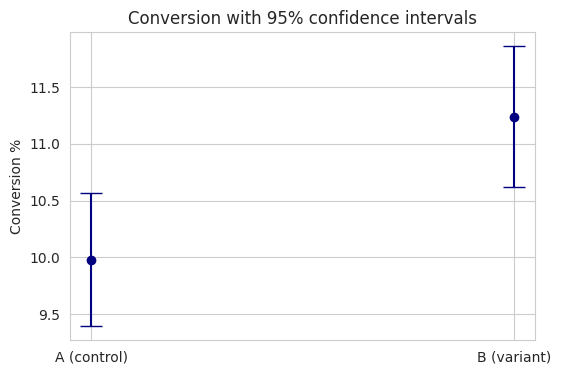

In [4]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

a = ab[ab["group"] == "A"]["converted"]
b = ab[ab["group"] == "B"]["converted"]
conv_a, conv_b = a.mean(), b.mean()
n_a, n_b = len(a), len(b)
x_a, x_b = a.sum(), b.sum()

print("Conversion A:", round(conv_a * 100, 2), "%")
print("Conversion B:", round(conv_b * 100, 2), "%")
print("Absolute lift:", round((conv_b - conv_a) * 100, 2), "percentage points")
print("Relative lift:", round((conv_b - conv_a) / conv_a * 100, 1), "%")

z, p = proportions_ztest([x_b, x_a], [n_b, n_a])
print("\nz =", round(z, 3), " p-value =", round(p, 5))

se = np.sqrt(conv_a * (1 - conv_a) / n_a + conv_b * (1 - conv_b) / n_b)
diff = conv_b - conv_a
ci_low, ci_high = diff - 1.96 * se, diff + 1.96 * se
print("95% CI for the difference:", round(ci_low * 100, 2), "to", round(ci_high * 100, 2), "percentage points")

table = [[x_a, n_a - x_a], [x_b, n_b - x_b]]
chi2, p_chi, dof, exp = stats.chi2_contingency(table, correction=False)
print("Chi-square test p-value:", round(p_chi, 5), "(should match the z-test)")

fig, ax = plt.subplots(figsize=(6, 4))
lo_a, hi_a = proportion_confint(x_a, n_a)
lo_b, hi_b = proportion_confint(x_b, n_b)
ax.errorbar([0, 1], [conv_a * 100, conv_b * 100], yerr=[[(conv_a - lo_a) * 100, (conv_b - lo_b) * 100], [(hi_a - conv_a) * 100, (hi_b - conv_b) * 100]],
            fmt="o", capsize=8, color="navy")
ax.set_xticks([0, 1])
ax.set_xticklabels(["A (control)", "B (variant)"])
ax.set_ylabel("Conversion %")
ax.set_title("Conversion with 95% confidence intervals")
plt.show()

## Step 5: Effect size and power analysis

In [5]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

h = proportion_effectsize(conv_b, conv_a)
print("Cohen's h (effect size):", round(h, 4), "(0.2 = small, 0.5 = medium)")

power_tool = NormalIndPower()
h_min = power_tool.solve_power(nobs1=n_a, alpha=0.05, power=0.8, ratio=n_b / n_a)
p_min = np.sin(np.arcsin(np.sqrt(conv_a)) + h_min / 2) ** 2
mde_pp = (p_min - conv_a) * 100
print("With", n_a, "users per group, this test could reliably (80% of the time) detect a lift of about", round(mde_pp, 2), "percentage points or more.")
print("Smaller lifts could easily be missed. (We do not compute 'power of the observed effect', because that number only repeats the p-value.)")

print("\nUsers needed per group to detect a lift (alpha 0.05, power 0.8), starting from the control rate:")
rows = []
for mde in [0.005, 0.01, 0.02, 0.03]:
    eff = proportion_effectsize(conv_a + mde, conv_a)
    n_needed = power_tool.solve_power(effect_size=eff, alpha=0.05, power=0.8, ratio=1)
    rows.append({"lift_to_detect_pp": mde * 100, "users_per_group": int(np.ceil(n_needed))})
print(pd.DataFrame(rows))

Cohen's h (effect size): 0.0409 (0.2 = small, 0.5 = medium)
With 10000 users per group, this test could reliably (80% of the time) detect a lift of about 1.22 percentage points or more.
Smaller lifts could easily be missed. (We do not compute 'power of the observed effect', because that number only repeats the p-value.)

Users needed per group to detect a lift (alpha 0.05, power 0.8), starting from the control rate:
   lift_to_detect_pp  users_per_group
0                0.5            57656
1                1.0            14720
2                2.0             3829
3                3.0             1766


## Step 6: Revenue per user
Revenue is not normal (many zeros and a long tail), so we check it with three methods.

Revenue per user A: 8.02  B: 9.27
Welch t-test p-value: 0.004
Mann-Whitney p-value: 0.0034
Bootstrap 95% CI for revenue difference per user: 0.37 to 2.06

Average order value (only buyers) A: 80.38  B: 82.47


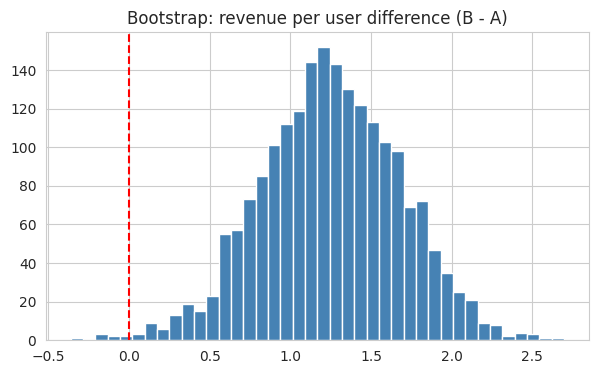

In [6]:
rev_a = ab[ab["group"] == "A"]["revenue"]
rev_b = ab[ab["group"] == "B"]["revenue"]
print("Revenue per user A:", round(rev_a.mean(), 2), " B:", round(rev_b.mean(), 2))

t, p_t = stats.ttest_ind(rev_b, rev_a, equal_var=False)
print("Welch t-test p-value:", round(p_t, 4))

u, p_u = stats.mannwhitneyu(rev_b, rev_a, alternative="two-sided")
print("Mann-Whitney p-value:", round(p_u, 4))

boot_diffs = []
for i in range(2000):
    sa = rev_a.sample(len(rev_a), replace=True).mean()
    sb = rev_b.sample(len(rev_b), replace=True).mean()
    boot_diffs.append(sb - sa)
low, high = np.percentile(boot_diffs, [2.5, 97.5])
print("Bootstrap 95% CI for revenue difference per user:", round(low, 2), "to", round(high, 2))

paid_a = ab[(ab["group"] == "A") & (ab["converted"] == 1)]["revenue"]
paid_b = ab[(ab["group"] == "B") & (ab["converted"] == 1)]["revenue"]
print("\nAverage order value (only buyers) A:", round(paid_a.mean(), 2), " B:", round(paid_b.mean(), 2))

plt.figure(figsize=(7, 4))
plt.hist(boot_diffs, bins=40, color="steelblue")
plt.axvline(0, color="red", linestyle="--")
plt.title("Bootstrap: revenue per user difference (B - A)")
plt.show()

## Step 7: Segments and multiple testing
If you check many segments, some will look significant by luck. We correct for that.

In [7]:
from statsmodels.stats.multitest import multipletests

rows = []
for col in ["device", "country"]:
    for value in ab[col].unique():
        sub = ab[ab[col] == value]
        sa = sub[sub["group"] == "A"]["converted"]
        sb = sub[sub["group"] == "B"]["converted"]
        if len(sa) < 100 or len(sb) < 100:
            continue
        z_seg, p_seg = proportions_ztest([sb.sum(), sa.sum()], [len(sb), len(sa)])
        rows.append({"segment": col + " = " + str(value), "users": len(sub), "conv_A_pct": sa.mean() * 100,
                     "conv_B_pct": sb.mean() * 100, "lift_pp": (sb.mean() - sa.mean()) * 100, "p_value": p_seg})
seg = pd.DataFrame(rows)
seg["p_bonferroni"] = multipletests(seg["p_value"], method="bonferroni")[1]
seg["p_bh"] = multipletests(seg["p_value"], method="fdr_bh")[1]
seg["significant_after_bh"] = seg["p_bh"] < 0.05
print(seg.round(4).sort_values("p_value"))

import statsmodels.formula.api as smf
m_full = smf.logit("converted ~ C(group) * C(device)", data=ab).fit(disp=0)
m_small = smf.logit("converted ~ C(group) + C(device)", data=ab).fit(disp=0)
lr_stat = 2 * (m_full.llf - m_small.llf)
df_diff = m_full.df_model - m_small.df_model
p_interaction = float(stats.chi2.sf(lr_stat, df_diff))
print("\nDoes the effect of B differ by device? Interaction test p-value:", round(p_interaction, 4))
if p_interaction < 0.05:
    print("Yes. The effect is not the same on every device, so one overall average hides the story.")
else:
    print("No clear difference between devices.")

             segment  users  conv_A_pct  conv_B_pct  lift_pp  p_value  \
1    device = mobile  12069      9.9542     12.0617   2.1076   0.0002   
4    country = India   9935      9.7853     11.0822   1.2970   0.0345   
5      country = USA   4980      9.9920     11.4952   1.5032   0.0867   
2    device = tablet   1933      9.1571     10.8025   1.6453   0.2276   
3       country = UK   3071     10.0580     11.3158   1.2578   0.2592   
0   device = desktop   5998     10.3037      9.7815  -0.5221   0.5012   
6  country = Germany   2014     10.7738     11.2790   0.5052   0.7174   

   p_bonferroni    p_bh  significant_after_bh  
1        0.0015  0.0015                  True  
4        0.2416  0.1208                 False  
5        0.6072  0.2024                 False  
2        1.0000  0.3629                 False  
3        1.0000  0.3629                 False  
0        1.0000  0.5847                 False  
6        1.0000  0.7174                 False  

Does the effect of B differ by

## Step 8: The peeking problem
We run many A/A tests (no real difference) and check results every day. Stopping at the first p < 0.05 gives too many false winners.

In [8]:
n_sims = 2000
looks = 10
users_per_look = 200
false_peek = 0
false_single = 0

for s in range(n_sims):
    ra = np.random.rand(users_per_look * looks) < 0.10
    rb = np.random.rand(users_per_look * looks) < 0.10
    found = False
    for k in range(1, looks + 1):
        n_now = users_per_look * k
        xa, xb = ra[:n_now].sum(), rb[:n_now].sum()
        pooled = (xa + xb) / (2 * n_now)
        se_now = np.sqrt(pooled * (1 - pooled) * 2 / n_now)
        if se_now > 0:
            z_now = (xb - xa) / n_now / se_now
            if abs(z_now) > 1.96:
                found = True
    if found:
        false_peek += 1
    n_now = users_per_look * looks
    xa, xb = ra.sum(), rb.sum()
    pooled = (xa + xb) / (2 * n_now)
    se_now = np.sqrt(pooled * (1 - pooled) * 2 / n_now)
    if abs((xb - xa) / n_now / se_now) > 1.96:
        false_single += 1

margin = 1.96 * np.sqrt(0.05 * 0.95 / n_sims) * 100
print("False positive rate with ONE final look:", round(false_single / n_sims * 100, 1), "% (expected 5%, give or take", round(margin, 1), "because of", n_sims, "simulations)")
print("False positive rate when peeking", looks, "times:", round(false_peek / n_sims * 100, 1), "%")
print("Lesson: decide the sample size first, and look only once (or use a proper sequential method).")

False positive rate with ONE final look: 4.8 % (expected 5%, give or take 1.0 because of 2000 simulations)
False positive rate when peeking 10 times: 19.9 %
Lesson: decide the sample size first, and look only once (or use a proper sequential method).


## Step 9: Bayesian view

Probability B is better than A: 99.83 %
Expected conversion gain (pp): 1.258
Expected loss if we ship B and A was better (pp): 0.0002
95% credible interval for lift (pp): [0.41 2.11]


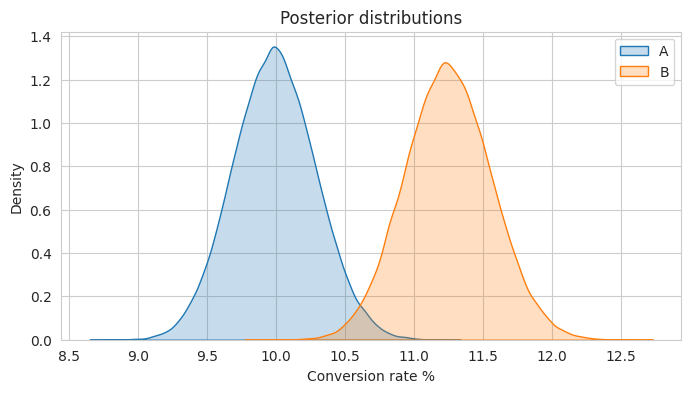

In [9]:
samples = 100000
post_a = np.random.beta(1 + x_a, 1 + n_a - x_a, samples)
post_b = np.random.beta(1 + x_b, 1 + n_b - x_b, samples)

prob_b_better = (post_b > post_a).mean()
expected_loss_b = np.maximum(post_a - post_b, 0).mean()
expected_gain = (post_b - post_a).mean()
print("Probability B is better than A:", round(prob_b_better * 100, 2), "%")
print("Expected conversion gain (pp):", round(expected_gain * 100, 3))
print("Expected loss if we ship B and A was better (pp):", round(expected_loss_b * 100, 4))
print("95% credible interval for lift (pp):", np.round(np.percentile((post_b - post_a) * 100, [2.5, 97.5]), 2))

plt.figure(figsize=(8, 4))
sns.kdeplot(post_a * 100, label="A", fill=True)
sns.kdeplot(post_b * 100, label="B", fill=True)
plt.xlabel("Conversion rate %")
plt.title("Posterior distributions")
plt.legend()
plt.show()

## Step 10: Decision

In [10]:
print("DECISION SUMMARY (calculated from this run)")
print("Sample ratio OK:", chi.pvalue >= 0.01)
print("Conversion lift:", round((conv_b - conv_a) * 100, 2), "pp, p-value", round(p, 5), ", CI", round(ci_low * 100, 2), "to", round(ci_high * 100, 2))
print("Revenue per user Welch p-value:", round(p_t, 4))
print("Probability B better (Bayesian):", round(prob_b_better * 100, 1), "%")

if chi.pvalue < 0.01:
    decision = "DO NOT TRUST - fix the split first"
elif p < 0.05 and ci_low > 0:
    if p_t < 0.05 and rev_b.mean() < rev_a.mean():
        decision = "HOLD - conversion is up but revenue per user is down"
    else:
        decision = "SHIP variant B"
elif p < 0.05 and ci_high < 0:
    decision = "DO NOT SHIP - variant B is worse"
else:
    decision = "NO CLEAR WINNER - keep testing or keep A"
desktop_row = seg[seg["segment"] == "device = desktop"]
if decision == "SHIP variant B" and p_interaction < 0.05 and len(desktop_row) > 0 and desktop_row.iloc[0]["lift_pp"] <= 0:
    decision = "SHIP variant B on mobile first. Desktop showed no gain (lift " + str(round(desktop_row.iloc[0]["lift_pp"], 2)) + " pp), so watch or hold desktop"
print("\nRecommendation:", decision)
print("Interaction test (does the effect differ by device) p-value:", round(p_interaction, 4))
print("Primary metric: conversion. Revenue per user and the segments are secondary checks and were not used to pick the winner.")

good_segments = seg[seg["significant_after_bh"]]["segment"].tolist()
print("Segments with a real lift after correction:", good_segments)

seg.to_csv("abtest_segments.csv", index=False)
ab.to_csv("abtest_data.csv", index=False)
print("\nSaved abtest_segments.csv and abtest_data.csv")

DECISION SUMMARY (calculated from this run)
Sample ratio OK: True
Conversion lift: 1.26 pp, p-value 0.00382 , CI 0.41 to 2.11
Revenue per user Welch p-value: 0.004
Probability B better (Bayesian): 99.8 %

Recommendation: SHIP variant B on mobile first. Desktop showed no gain (lift -0.52 pp), so watch or hold desktop
Interaction test (does the effect differ by device) p-value: 0.0295
Primary metric: conversion. Revenue per user and the segments are secondary checks and were not used to pick the winner.
Segments with a real lift after correction: ['device = mobile']

Saved abtest_segments.csv and abtest_data.csv



---
Built by **Akshat Kesharwani** | [GitHub](https://github.com/akshatkesharwani-info) | [Portfolio](https://akshatkesharwani-info.github.io/)